In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
data = pd.read_csv('mera.csv')


C:\Users\animi\AppData\Local\Temp\ipykernel_27604\3455810264.py:1: DtypeWarning: Columns (24,25,26,27,31,33,34,38,39,43) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('mera.csv')


In [3]:
feature_cols = [
    'curr_ann_amt', 'days_tenure', 'age_in_years', 'income', 'has_children',
    'length_of_residence', 'marital_status', 'home_owner', 'college_degree', 'good_credit'
]
target_col = 'Churn'
df = data[feature_cols + [target_col]].dropna()

In [4]:
categorical_cols = ['marital_status', 'home_owner', 'college_degree', 'good_credit', 'has_children']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [5]:
import joblib
import os
joblib.dump(le, 'front/label_encoders.pkl')

['front/label_encoders.pkl']

In [6]:
X = df[feature_cols]
y = df[target_col]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
rf_clf = RandomForestClassifier(n_estimators=250, random_state=42)
rf_clf.fit(X_train, y_train)
rf_preds = rf_clf.predict(X_test)
print(f'Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.4f}')

Random Forest Accuracy: 0.8822


In [9]:
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train, y_train)
xgb_preds = xgb_clf.predict(X_test)
print(f'XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.4f}')

c:\Users\animi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [05:04:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8843


C:\Users\animi\AppData\Local\Temp\ipykernel_27604\3109958169.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_feat_imp.values, y=rf_feat_imp.index, palette='viridis')


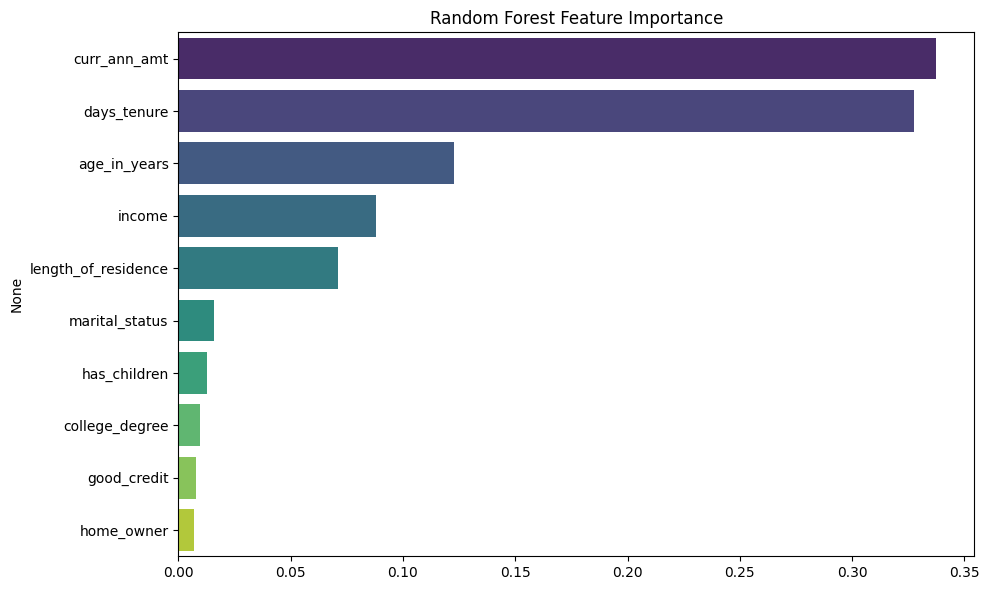

In [10]:
rf_feat_imp = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=rf_feat_imp.values, y=rf_feat_imp.index, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()


C:\Users\animi\AppData\Local\Temp\ipykernel_27604\1488346182.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_imp.values, y=xgb_imp.index, palette='coolwarm')


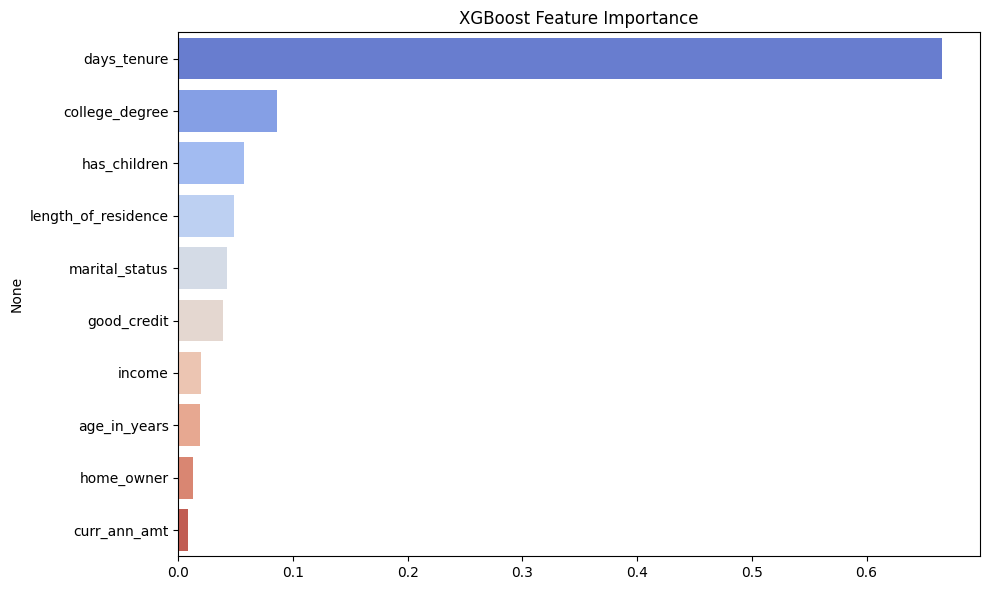

In [11]:
xgb_imp = pd.Series(xgb_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=xgb_imp.values, y=xgb_imp.index, palette='coolwarm')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()


In [12]:
joblib.dump(rf_clf, 'front/rf_model.pkl')
joblib.dump(xgb_clf, 'front/xgb_model.pkl')

['front/xgb_model.pkl']